In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
raw = pd.read_csv('AB_NYC_2019.csv')

In [4]:
raw.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [5]:
raw

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [6]:
Private_room = raw['room_type'].unique()
Private_room

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

In [7]:
Private_room_no=raw['room_type'].nunique()
Private_room_no

3

In [8]:
pr = raw['room_type'].value_counts()
pr

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

In [9]:
prunique=raw['price'].unique()
prunique

array([  149,   225,   150,    89,    80,   200,    60,    79,   135,
          85,   120,   140,   215,    99,   190,   299,   130,   110,
          44,   180,    50,    52,    55,    70,    35,    40,    68,
         115,   151,   228,   144,    69,    49,   375,   250,   275,
         230,    51,    65,   105,    95,   145,   285,    94,   800,
         131,    98,   100,   125,   175,   500,   101,   220,    59,
         350,   199,   325,   235,   170,   400,    75,    90,   185,
          77,    76,   160,   195,   156,   219,   475,   165,   196,
          83,   123,   265,   249,   121,    45,    71,    64,   159,
         189,   239,   305,   155,    92,    36,    37,   205,    39,
         390,   129,   212,   124,   122,   109,   575,   229,   169,
         113,   179,   349,   139,   650,    67,   599,   211,   290,
          87,   395,   260,    97,   132,   141,   495,   259,    96,
         295,   451,   300,    42,   255,    72,    88,   450,   198,
          46,    33,

In [10]:

pr1= raw['price'].value_counts().sort_index()
pr1

price
0        11
10       17
11        3
12        4
13        1
         ..
7703      1
8000      1
8500      1
9999      3
10000     3
Name: count, Length: 674, dtype: int64

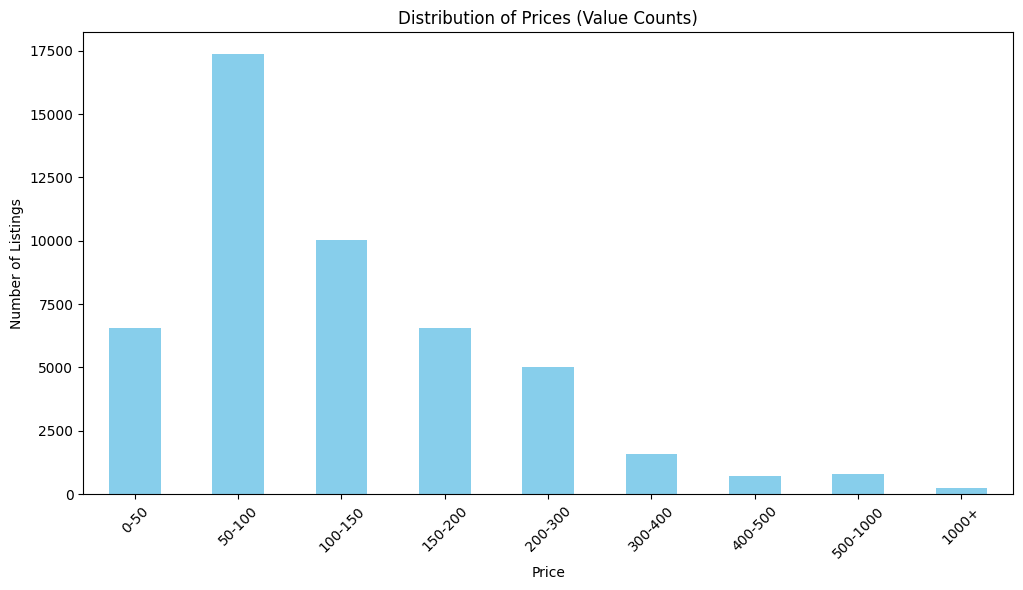

In [11]:
plt.figure(figsize=(12,6))
bins=[0,50,100,150,200,300,400, 500,1000,5000]
labels=['0-50','50-100','100-150','150-200','200-300','300-400','400-500','500-1000','1000+']
raw['price_range']= pd.cut(raw['price'],bins=bins, labels=labels,include_lowest=True)
pr12= raw['price_range'].value_counts().sort_index()
pr12.plot(kind='bar',color='skyblue')
plt.title('Distribution of Prices (Value Counts)')
plt.xlabel('Price')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45)
plt.show()

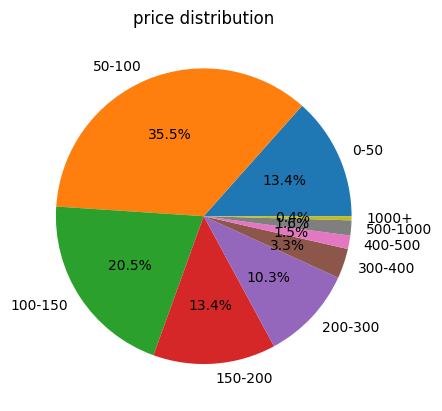

In [12]:
plt.pie(pr12, labels=pr12.index, autopct='%1.1f%%')
plt.title('price distribution')
plt.show()

The chart above is ugly due to many unique values that exist in our pie chart and hence this chart is not appropriate for the pictorial representation of this data

In [13]:
raw['last_review']=pd.to_datetime(raw['last_review'])

In [14]:
raw.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,price_range
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,100-150
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,200-300
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,NaN,1,365,100-150
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,50-100
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,50-100


In [15]:
least_recent_reviews = raw['last_review'].min()
least_recent_reviews


Timestamp('2011-03-28 00:00:00')

In [16]:
most_recent_reviews = raw['last_review'].max()
most_recent_reviews

Timestamp('2019-07-08 00:00:00')

In [17]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48895 non-null  int64         
 1   name                            48879 non-null  object        
 2   host_id                         48895 non-null  int64         
 3   host_name                       48874 non-null  object        
 4   neighbourhood_group             48895 non-null  object        
 5   neighbourhood                   48895 non-null  object        
 6   latitude                        48895 non-null  float64       
 7   longitude                       48895 non-null  float64       
 8   room_type                       48895 non-null  object        
 9   price                           48895 non-null  int64         
 10  minimum_nights                  48895 non-null  int64         
 11  nu

<Axes: xlabel='id', ylabel='price'>

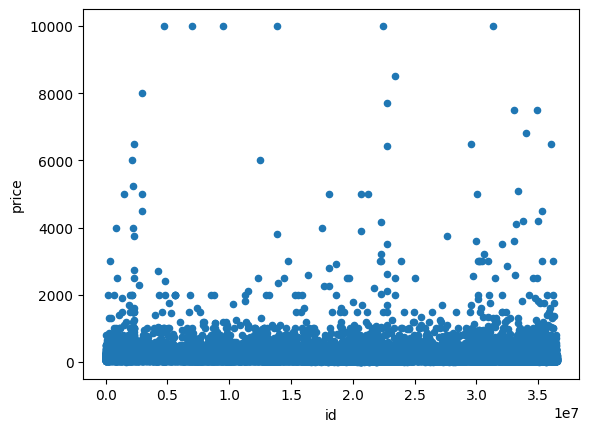

In [18]:
raw.plot.scatter('id','price')

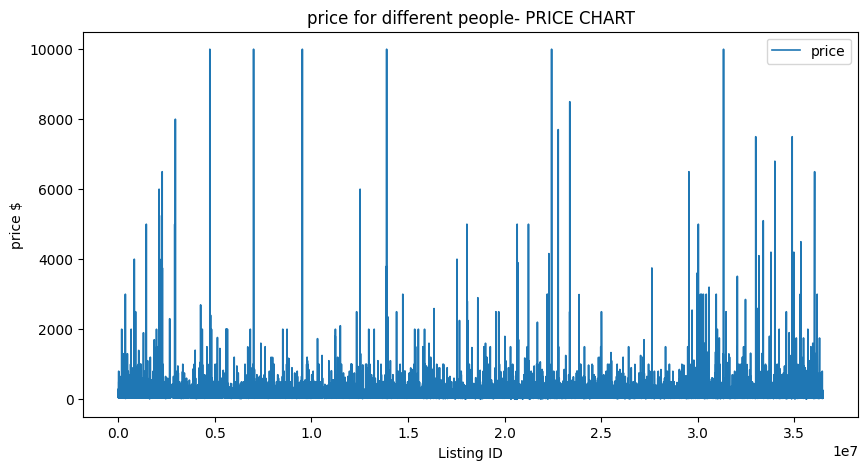

In [19]:
raw.plot(x='id',y='price', kind='line',figsize=(10,5),linewidth=1.2)
plt.title("price for different people- PRICE CHART")
plt.xlabel("Listing ID")
plt.ylabel("price $")
# plt.grid(True, linestyle='--',alpha=0.5)
plt.show()


In [20]:
raw

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,price_range
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,100-150
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,200-300
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,NaN,1,365,100-150
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,50-100
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,50-100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaT,NaN,2,9,50-100
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaT,NaN,2,36,0-50
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaT,NaN,1,27,100-150
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaT,NaN,6,2,50-100


In [31]:
nuni = raw.groupby('neighbourhood_group')['calculated_host_listings_count'].count().sort_values()
nuni

neighbourhood_group
Staten Island      373
Bronx             1091
Queens            5666
Brooklyn         20104
Manhattan        21661
Name: calculated_host_listings_count, dtype: int64

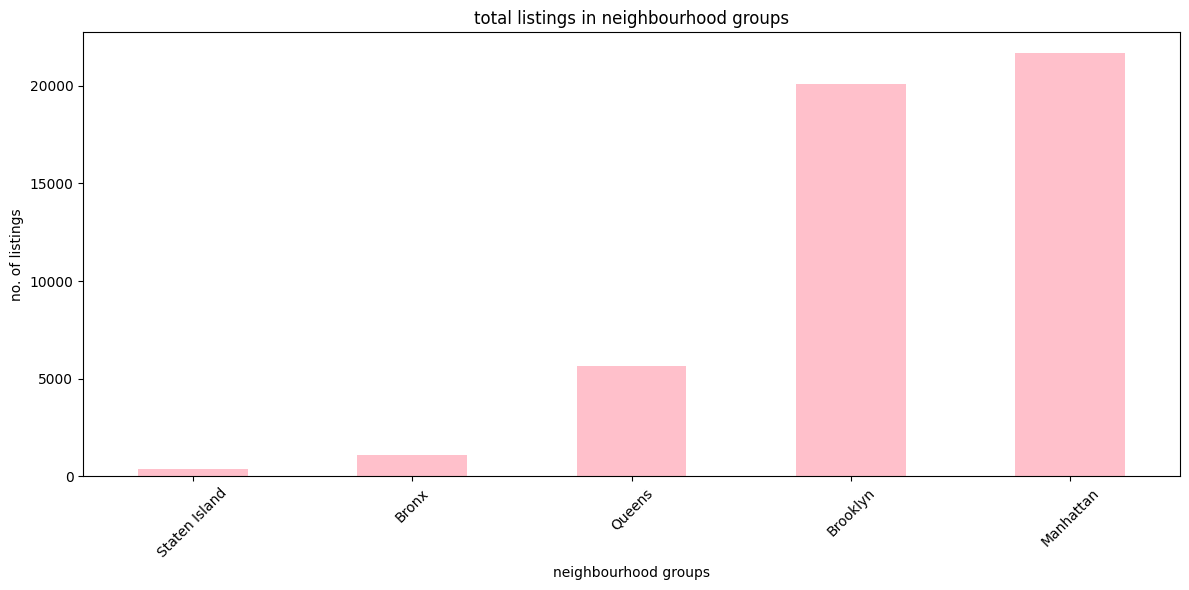

In [37]:
plt.figure(figsize=(12,6))
nuni.plot.bar(color='pink')
plt.xticks(rotation=45)
plt.title('total listings in neighbourhood groups')
plt.xlabel('neighbourhood groups')
plt.ylabel('no. of listings')
plt.tight_layout()
plt.show()


In [38]:
raw

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,price_range
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,100-150
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,200-300
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,NaN,1,365,100-150
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,50-100
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,50-100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaT,NaN,2,9,50-100
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaT,NaN,2,36,0-50
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaT,NaN,1,27,100-150
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaT,NaN,6,2,50-100


In [49]:
nyc_metrics=raw.groupby('neighbourhood_group').agg({
    'price':'mean',
    'number_of_reviews':'mean',
    'reviews_per_month':'mean',
    'availability_365':'mean',
    'calculated_host_listings_count':'count'
}).rename(columns={'calculated_host_listings_count': 'total_listings','price':'avg_price','number_of_reviews':'mean_no.of_reviews','reviews_per_month':'mean_reviews_per_month','availability_365':'mean_availability'})
nyc_metrics

,avg_price,mean_no.of_reviews,mean_reviews_per_month,mean_availability,total_listings
neighbourhood_group,,,,,
Bronx,87.496792,26.004583,1.837831,165.758937,1091
Brooklyn,124.383207,24.202845,1.283212,100.232292,20104
Manhattan,196.875814,20.985596,1.272131,111.979410,21661
Queens,99.517649,27.700318,1.941200,144.451818,5666
Staten Island,114.812332,30.941019,1.872580,199.678284,373


In [52]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled = scaler.fit_transform(nyc_metrics)

nyc_scaled = pd.DataFrame(scaled,columns = nyc_metrics.columns, index= nyc_metrics.index)
nyc_scaled

,avg_price,mean_no.of_reviews,mean_reviews_per_month,mean_availability,total_listings
neighbourhood_group,,,,,
Bronx,0.000000,0.504146,0.845503,0.658917,0.033728
Brooklyn,0.337235,0.323165,0.016561,0.000000,0.926860
Manhattan,1.000000,0.000000,0.000000,0.118126,1.000000
Queens,0.109901,0.674479,1.000000,0.444659,0.248638
Staten Island,0.249733,1.000000,0.897439,1.000000,0.000000


Here’s a balanced formula tuned for this dataset(assumed):

Metric	Weight	Logic
Price	0.35	Cheaper = better
Number of Reviews	0.25	Popularity
Reviews per Month	0.25	Consistent engagement
Availability	0.15	Easier booking

In [53]:
nyc_scaled['avg_price']=1-nyc_scaled['avg_price']

In [57]:
nyc_scaled['traveler_score']=(
    0.35 * nyc_scaled['avg_price'] +
    0.25 * nyc_scaled['mean_no.of_reviews'] +
    0.25 * nyc_scaled['mean_reviews_per_month'] +
    0.15 * nyc_scaled['mean_availability']
)

In [58]:
top_travel_locations = nyc_scaled.sort_values('traveler_score', ascending=False).head(10)
top_travel_locations

,avg_price,mean_no.of_reviews,mean_reviews_per_month,mean_availability,total_listings,travelers score,traveler_score
neighbourhood_group,,,,,,,
Staten Island,0.750267,1.000000,0.897439,1.000000,0.000000,0.886953,0.886953
Queens,0.890099,0.674479,1.000000,0.444659,0.248638,0.796853,0.796853
Bronx,1.000000,0.504146,0.845503,0.658917,0.033728,0.786250,0.786250
Brooklyn,0.662765,0.323165,0.016561,0.000000,0.926860,0.316900,0.316900
Manhattan,0.000000,0.000000,0.000000,0.118126,1.000000,0.017719,0.017719


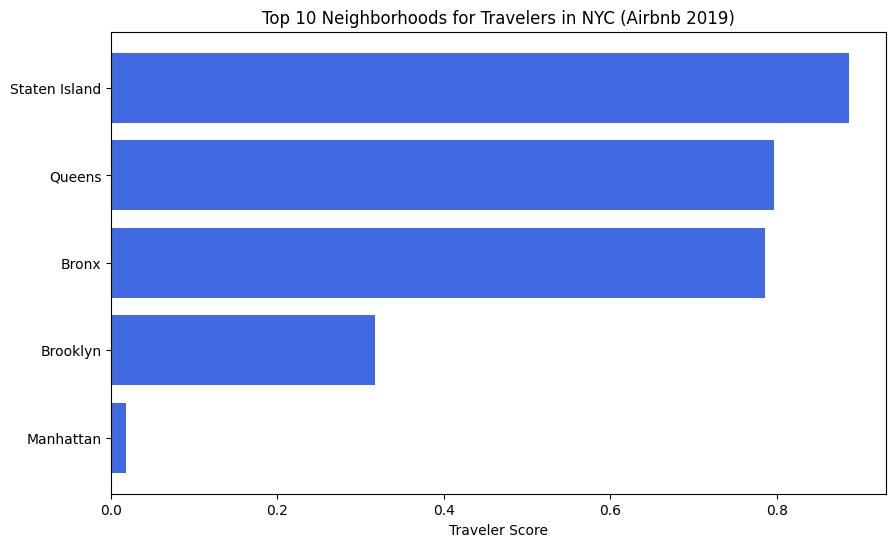

In [59]:

plt.figure(figsize=(10,6))
plt.barh(top_travel_locations.index, top_travel_locations['traveler_score'], color='royalblue')
plt.xlabel('Traveler Score')
plt.title('Top 10 Neighborhoods for Travelers in NYC (Airbnb 2019)')
plt.gca().invert_yaxis()
plt.show()